In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# 1. LOAD THE DATA (Using the paths from your group's repository)
SHADOW_PATH = "shadow_hubs_residual_2019plus.csv"
NODES_PATH = "nodes_country_oil_2019plus.csv"

shadow_df = pd.read_csv(SHADOW_PATH)
nodes_df = pd.read_csv(NODES_PATH)

In [5]:
shadow_df.head()

,year,iso3,betweenness,trade_total_usd,in_deg,out_deg,prune_threshold_usd,edges_after_pruning,nodes_after_pruning,log_btw,log_vol,btw_expected,shadow_resid,shadow_rank
0,2019,COL,0.011684,6.830752e+10,45,51,0.001,8111,237,0.011616,24.947286,0.055398,-0.043782,70.0
1,2019,NLD,0.201190,2.235856e+11,107,184,0.001,8111,237,0.183313,26.133060,0.079287,0.104025,3.0
2,2019,PAN,0.004237,2.495475e+10,63,24,0.001,8111,237,0.004228,23.940330,0.035111,-0.030883,60.0
3,2019,USA,0.329463,6.010105e+11,115,181,0.001,8111,237,0.284775,27.121878,0.099209,0.185566,1.0
4,2019,AGO,0.002939,6.409265e+10,45,28,0.001,8111,237,0.002935,24.883595,0.054115,-0.051180,72.0


In [6]:
nodes_df.head()

,country_iso3,country_name,iso2,code,is_group,ofac_entities,ofac_entity_country_links
0,ABW,Aruba,AW,533,False,1,1
1,AFG,Afghanistan,AF,4,False,82,82
2,AGO,Angola,AO,24,False,11,11
3,AIA,Anguilla,AI,660,False,0,0
4,ALB,Albania,AL,8,False,8,8


In [9]:


# 2. MERGE RISK DATA
# We join the residual scores with the OFAC entity counts from the nodes file
df_analyst = pd.merge(
    shadow_df,
    nodes_df[['country_iso3', 'ofac_entities', 'country_name']],
    left_on='iso3',
    right_on='country_iso3',
    how='left'
)
df_analyst.head()

,year,iso3,betweenness,trade_total_usd,in_deg,out_deg,prune_threshold_usd,edges_after_pruning,nodes_after_pruning,log_btw,log_vol,btw_expected,shadow_resid,shadow_rank,country_iso3,ofac_entities,country_name
0,2019,COL,0.011684,6.830752e+10,45,51,0.001,8111,237,0.011616,24.947286,0.055398,-0.043782,70.0,COL,383,Colombia
1,2019,NLD,0.201190,2.235856e+11,107,184,0.001,8111,237,0.183313,26.133060,0.079287,0.104025,3.0,NLD,58,Netherlands
2,2019,PAN,0.004237,2.495475e+10,63,24,0.001,8111,237,0.004228,23.940330,0.035111,-0.030883,60.0,PAN,144,Panama
3,2019,USA,0.329463,6.010105e+11,115,181,0.001,8111,237,0.284775,27.121878,0.099209,0.185566,1.0,USA,75,USA
4,2019,AGO,0.002939,6.409265e+10,45,28,0.001,8111,237,0.002935,24.883595,0.054115,-0.051180,72.0,AGO,11,Angola


In [17]:


# 3. ANALYSIS: Identify "The Jumpers" (Pre- vs. Post-2022 Sanctions)
# We compare the shadow residual from 2021 to 2024
pivot = df_analyst.pivot(index='iso3', columns='year', values='shadow_resid').fillna(0)
pivot['shadow_growth'] = pivot[2024] - pivot[2021]
pivot.head()

year,2019,2020,2021,2022,2023,2024,shadow_growth
iso3,,,,,,,
AGO,-0.051180,-0.048406,-0.042576,-0.035469,-0.040525,-0.022223,0.020354
ARE,-0.002213,-0.023209,-0.006991,-0.013115,-0.012060,0.000000,0.006991
ARG,0.006205,0.015981,0.007327,-0.007522,-0.000406,-0.002147,-0.009474
AUS,-0.025945,-0.030301,-0.024727,-0.036636,-0.026862,-0.022713,0.002014
AUT,-0.023108,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [18]:
# Create a lookup dictionary for ISO3 to Country Name
name_lookup = df_analyst.set_index('iso3')['country_name'].to_dict()

print("\n--- Top 10 Emerging Shadow Hubs (Post-2022 Growth) ---")
# Reset index to turn ISO3 into a column, then map the name
emerging_results = emerging_hubs[['shadow_growth']].copy()
emerging_results['country_name'] = emerging_results.index.map(name_lookup)

# Reorder columns for better readability
print(emerging_results[['country_name', 'shadow_growth']])


--- Top 10 Emerging Shadow Hubs (Post-2022 Growth) ---
year    country_name  shadow_growth
iso3                               
ESP            Spain       0.094124
ITA            Italy       0.046326
BEL          Belgium       0.033717
KOR    Rep. of Korea       0.033595
GBR   United Kingdom       0.032156
GRC           Greece       0.024308
COL         Colombia       0.024080
AGO           Angola       0.020354
SAU     Saudi Arabia       0.016809
FRA           France       0.016049


In [13]:

# Top 10 countries that became significantly more "Shadow-like" after 2022
emerging_hubs = pivot.sort_values('shadow_growth', ascending=False).head(10)
emerging_hubs

year,2019,2020,2021,2022,2023,2024,shadow_growth
iso3,,,,,,,
ESP,0.086469,0.003995,-0.026427,-0.006991,-0.007603,0.067697,0.094124
ITA,-0.034087,-0.045550,-0.034011,-0.030454,-0.003869,0.012315,0.046326
BEL,-0.044934,NaN,-0.035711,-0.040139,-0.024177,-0.001993,0.033717
KOR,0.004803,-0.033641,-0.029695,-0.014237,-0.001645,0.003899,0.033595
GBR,0.015665,0.001730,-0.028385,-0.015588,-0.032341,0.003771,0.032156
GRC,-0.014362,-0.037892,-0.024728,-0.009286,-0.022631,-0.000420,0.024308
COL,-0.043782,-0.033186,-0.039096,-0.037652,-0.049242,-0.015016,0.024080
AGO,-0.051180,-0.048406,-0.042576,-0.035469,-0.040525,-0.022223,0.020354
SAU,NaN,NaN,-0.071376,NaN,NaN,-0.054567,0.016809


In [14]:
# 4. ANALYSIS: The "Risk-Residual" Correlation
# Does being a bridge (high residual) correlate with being connected to sanctioned entities?
correlation = df_analyst[['shadow_resid', 'ofac_entities']].corr().iloc[0,1]

print(f"Correlation between Shadow Score and OFAC Exposure: {correlation:.4f}")
print("\n--- Top 10 Emerging Shadow Hubs (Post-2022 Growth) ---")
print(emerging_hubs['shadow_growth'])

Correlation between Shadow Score and OFAC Exposure: -0.0557

--- Top 10 Emerging Shadow Hubs (Post-2022 Growth) ---
iso3
ESP    0.094124
ITA    0.046326
BEL    0.033717
KOR    0.033595
GBR    0.032156
GRC    0.024308
COL    0.024080
AGO    0.020354
SAU    0.016809
FRA    0.016049
Name: shadow_growth, dtype: float64


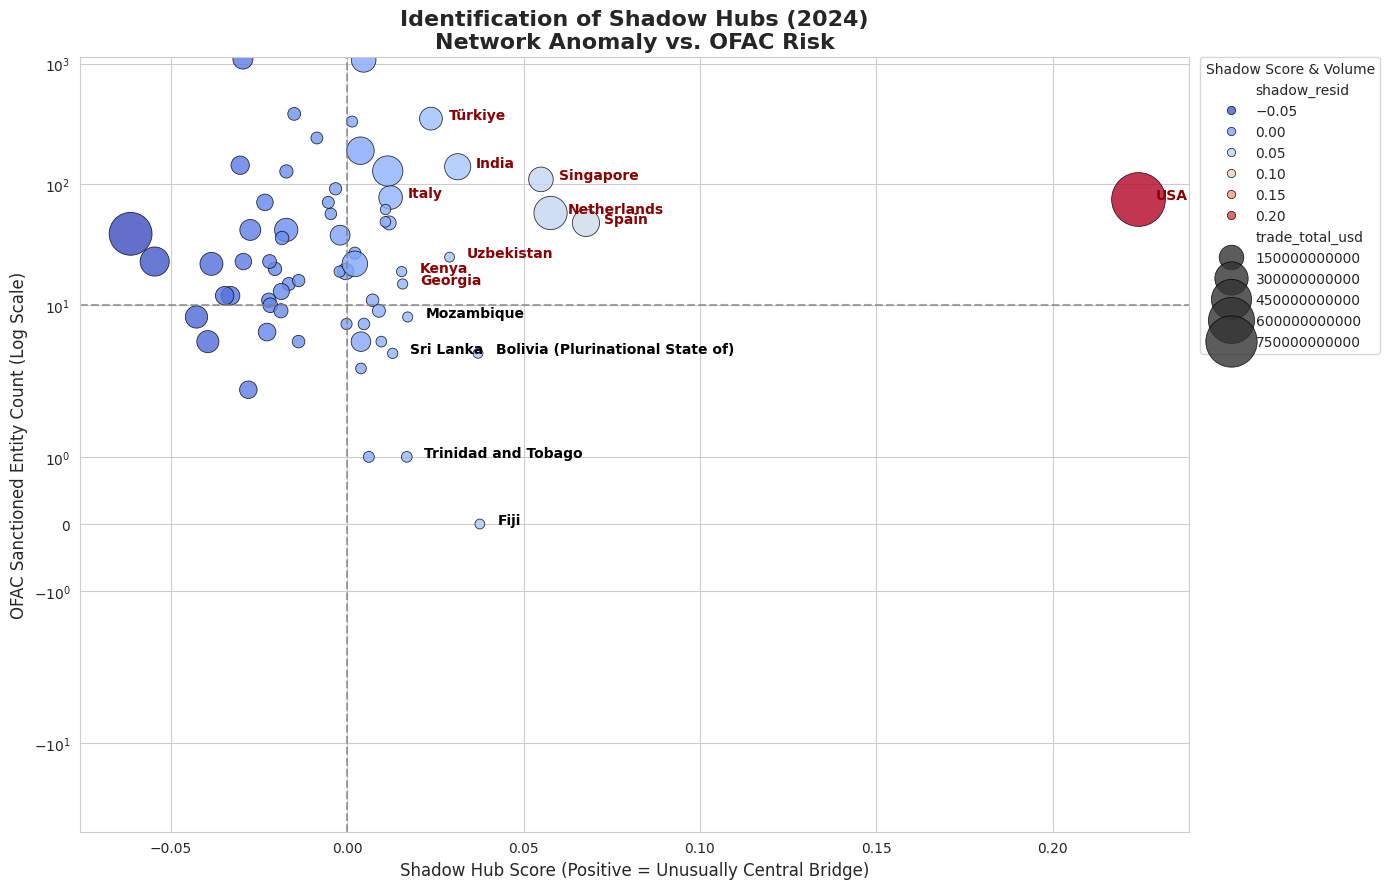

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for the latest data
latest_year = df_analyst['year'].max()
latest_data = df_analyst[df_analyst['year'] == latest_year].copy()

# 2. Setup the Figure
plt.figure(figsize=(14, 9))
sns.set_style("whitegrid")

# 3. Create the scatter plot
# Using raw trade volume for size, but giving it a wider range (50 to 1500)
# 'coolwarm' palette: Blues = Negative Residual (Normal), Reds = Positive Residual (Shadows)
scatter = sns.scatterplot(
    data=latest_data,
    x='shadow_resid',
    y='ofac_entities',
    size='trade_total_usd',
    hue='shadow_resid',
    palette='coolwarm',
    sizes=(50, 1500),
    alpha=0.8,
    edgecolor='black'
)

# 4. PRO-ANALYST FIX: Use a Symmetric Log Scale for the Y-Axis
# This prevents countries with 5000 sanctions from squashing countries with 50 sanctions
plt.yscale('symlog')

# 5. Draw "Quadrant" Reference Lines
# Vertical line at 0: Anything to the right is acting as an anomalous bridge
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
# Horizontal line: Arbitrary risk threshold (e.g., 10 OFAC entities)
plt.axhline(y=10, color='gray', linestyle='--', alpha=0.7)

# 6. LABEL THE TOP SUSPECTS (Fixing the Country Name issue)
# Instead of a complex quantile loop, just grab the top 15 by shadow score
top_suspects = latest_data.sort_values(by='shadow_resid', ascending=False).head(15)

for i, row in top_suspects.iterrows():
    plt.text(
        row['shadow_resid'] + 0.005,  # Add a tiny offset so text doesn't cover the bubble
        row['ofac_entities'],
        row['country_name'],          # <--- USING COUNTRY NAME HERE
        fontsize=10,
        fontweight='bold',
        # Highlight high-risk/high-anomaly names in dark red
        color='darkred' if (row['shadow_resid'] > 0 and row['ofac_entities'] > 10) else 'black'
    )

# 7. Final Formatting
plt.title(f"Identification of Shadow Hubs ({latest_year})\nNetwork Anomaly vs. OFAC Risk", fontsize=16, fontweight='bold')
plt.xlabel("Shadow Hub Score (Positive = Unusually Central Bridge)", fontsize=12)
plt.ylabel("OFAC Sanctioned Entity Count (Log Scale)", fontsize=12)

# Move the legend outside the plot so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0., title="Shadow Score & Volume")
plt.tight_layout()
plt.show()

In [25]:
import networkx as nx
import pandas as pd

# 1. Load the Edges and Create the Graph
edges = pd.read_csv("edges_country_oil_2019plus.csv")
edges_2024 = edges[edges['year'] == 2024]

# Create an undirected graph for structural analysis
G = nx.from_pandas_edgelist(
    edges_2024,
    source='exporter_iso3',
    target='importer_iso3',
    edge_attr='trade_value_usd',
    create_using=nx.Graph()
)

# 2. Calculate the Coefficients
# Unweighted: Just looks at the presence of edges
unweighted_cc = nx.clustering(G)

# Weighted: Factors in the trade volume (requires scaling the weights for NetworkX)
# We use log1p so massive routes don't completely break the algorithm
edges_2024['log_weight'] = np.log1p(edges_2024['trade_value_usd'])
G_weighted = nx.from_pandas_edgelist(
    edges_2024, source='exporter_iso3', target='importer_iso3', edge_attr='log_weight', create_using=nx.Graph()
)
weighted_cc = nx.clustering(G_weighted, weight='log_weight')

# 3. Map the results back to your Analyst Dataframe
df_analyst['clustering_unweighted'] = df_analyst['iso3'].map(unweighted_cc)
df_analyst['clustering_weighted'] = df_analyst['iso3'].map(weighted_cc)

# 4. View the results for your Top Suspects
top_suspects = df_analyst[df_analyst['year'] == 2024].sort_values('shadow_resid', ascending=False).head(10)

print("--- Clustering Analysis of Top Shadow Hubs ---")
top_suspects[['country_name', 'shadow_resid', 'clustering_unweighted', 'clustering_weighted']]

/tmp/ipykernel_1319/1895439469.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  edges_2024['log_weight'] = np.log1p(edges_2024['trade_value_usd'])


--- Clustering Analysis of Top Shadow Hubs ---


,country_name,shadow_resid,clustering_unweighted,clustering_weighted
363,USA,0.224350,0.310213,0.200772
351,Spain,0.067697,0.391588,0.242480
359,Netherlands,0.057659,0.322691,0.200610
361,Singapore,0.054936,0.315940,0.182441
382,Fiji,0.037603,0.544086,0.270115
371,Bolivia (Plurinational State of),0.037095,0.917647,0.505045
356,India,0.031328,0.352360,0.212388
410,Uzbekistan,0.029023,0.760959,0.422725
369,Türkiye,0.023758,0.289142,0.188349
412,Mozambique,0.017156,0.752252,0.435597
